# 04 — A/B Test Design: Win-Back Experiment
### Product Analytics & Experimentation: E-Commerce Funnel

**The story so far:** fulfillment is healthy (97% delivered), but only **3.1%** of customers return.
Retention is structurally low across every cohort; the few who return do so within a median of **~28 days**.
The first-purchase **category** predicts retention (home appliances ~7%, fashion bags ~5% vs. the 3.1%
baseline).

## 1. Setup

In [2]:
%pip install duckdb pandas numpy matplotlib statsmodels scipy
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest
from statsmodels.stats.power import NormalIndPower

con = duckdb.connect("../olist.duckdb")

needed = {
    "orders":    "olist_orders_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "payments":  "olist_order_payments_dataset.csv",
}
existing = {r[0] for r in con.execute("SHOW TABLES").fetchall()}
for name, file in needed.items():
    if name not in existing:
        con.execute(f"CREATE OR REPLACE TABLE {name} AS "
                    f"SELECT * FROM read_csv_auto('../data/{file}')")
print("ready")

Note: you may need to restart the kernel to use updated packages.
ready


## 2. Establish the baseline from real data

The control group's expected conversion is the current repeat-purchase rate. We recompute it here (rather than
hard-coding 3.1%) so the design rests on the actual data. We also pull the **average order value**, which we'll
need to translate any lift into money.

In [4]:
baseline = con.execute('''
    WITH per_customer AS (
        SELECT c.customer_unique_id, COUNT(*) AS n_orders
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_purchase_timestamp IS NOT NULL
        GROUP BY c.customer_unique_id
    )
    SELECT
        COUNT(*)                                                       AS customers,
        SUM(CASE WHEN n_orders > 1 THEN 1 ELSE 0 END)                  AS repeat_customers,
        AVG(CASE WHEN n_orders > 1 THEN 1.0 ELSE 0.0 END)             AS repeat_rate
    FROM per_customer
''').df()

p0 = float(baseline["repeat_rate"][0])          # control conversion rate
print(f"Baseline repeat-purchase rate (control): {p0:.4f}  ({p0*100:.2f}%)")

aov = con.execute('''
    SELECT AVG(order_value) AS aov FROM (
        SELECT order_id, SUM(payment_value) AS order_value
        FROM payments GROUP BY order_id
    )
''').df()["aov"][0]
print(f"Average order value: R$ {aov:,.2f}")

# Monthly acquisition volume sets how fast we can enroll customers into the test.
monthly = con.execute('''
    WITH first_orders AS (
        SELECT c.customer_unique_id,
               MIN(date_trunc('month', o.order_purchase_timestamp)) AS m
        FROM orders o JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_purchase_timestamp IS NOT NULL
        GROUP BY c.customer_unique_id
    )
    SELECT m, COUNT(*) AS new_customers FROM first_orders GROUP BY m
''').df()
# Use a typical steady-state month (median), ignoring the partial first/last months.
typical_monthly = int(monthly["new_customers"].median())
print(f"Typical new customers / month (median): {typical_monthly:,}")

Baseline repeat-purchase rate (control): 0.0312  (3.12%)
Average order value: R$ 160.99
Typical new customers / month (median): 4,130


## 3. The experiment design

| Element | Choice |
|---|---|
| **Unit of randomization** | Customer (`customer_unique_id`) who has placed a first order |
| **Intervention (treatment)** | Win-back email + small coupon, sent ~20 days after the first order (inside the ~28-day median return window) |
| **Control** | No nudge (business as usual) |
| **Primary metric** | Repeat-purchase rate — share who place a 2nd order within 90 days |
| **Guardrail metrics** | Average order value, coupon cost / margin, unsubscribe rate |
| **Assignment** | 50/50 random split |
| **Hypotheses** | H0: p_treatment = p_control  vs.  H1: p_treatment ≠ p_control |
| **Significance level (α)** | 0.05 |
| **Power (1−β)** | 0.80 |

We test two-sided at α = 0.05 with 80% power — the standard defaults.

## 4. Power analysis — how big a lift can we detect?

Two connected questions:
- **(a)** For a given target lift, how many customers per group do we need?
- **(b)** Given the customers we can realistically enroll, what's the smallest lift we can reliably detect (the *minimum detectable effect*, MDE)?

We use a two-proportion test (Cohen's *h* effect size).

In [9]:
analysis = NormalIndPower()

def required_n_per_arm(p0, p1, alpha=0.05, power=0.80, alternative="two-sided"):
    h = proportion_effectsize(p1, p0)
    return analysis.solve_power(effect_size=abs(h), alpha=alpha,
                                power=power, ratio=1.0, alternative=alternative)

# (a) Required sample size per arm for a range of RELATIVE lifts over the baseline.
rows = []
for rel in [0.10, 0.20, 0.30, 0.40, 0.50]:
    p1 = p0 * (1 + rel)
    rows.append({
        "relative_lift": f"{int(rel*100)}%",
        "p1 (new rate)": round(p1, 4),
        "n_per_arm": int(np.ceil(required_n_per_arm(p0, p1))),
        "total_n": int(np.ceil(required_n_per_arm(p0, p1)) * 2),
    })
sample_table = pd.DataFrame(rows)
sample_table

,relative_lift,p1 (new rate),n_per_arm,total_n
0,10%,0.0343,51091,102182
1,20%,0.0374,13340,26680
2,30%,0.0405,6175,12350
3,40%,0.0437,3609,7218
4,50%,0.0468,2395,4790


In [11]:
# (b) Given a feasible enrollment, find the MDE.
# Say we run for 8 weeks (~2 months) and enroll the typical monthly cohort each month.
test_weeks = 8
enrollable_total = int(typical_monthly * (test_weeks / 4.0))
n_per_arm_available = enrollable_total // 2
print(f"Enrollable over {test_weeks} weeks: ~{enrollable_total:,} customers  "
      f"(~{n_per_arm_available:,} per arm)")

# Scan relative lifts to find the smallest one our sample can detect.
mde_rel = None
for rel in np.arange(0.05, 1.01, 0.01):
    if required_n_per_arm(p0, p0 * (1 + rel)) <= n_per_arm_available:
        mde_rel = rel
        break

p1_mde = p0 * (1 + mde_rel)
print(f"\nMinimum detectable effect (80% power, α=0.05):")
print(f"  relative lift ≈ {mde_rel*100:.0f}%")
print(f"  repeat rate {p0*100:.2f}%  ->  {p1_mde*100:.2f}%  (absolute +{(p1_mde-p0)*100:.2f} pp)")

Enrollable over 8 weeks: ~8,260 customers  (~4,130 per arm)

Minimum detectable effect (80% power, α=0.05):
  relative lift ≈ 38%
  repeat rate 3.12%  ->  4.30%  (absolute +1.19 pp)


**This is the number for the design.** With the sample we can realistically enroll, the test is powered to
detect roughly the relative lift printed above. That is the *projected / target* lift the experiment is built
around — the honest figure to cite, framed as "powered to detect," not "achieved."

## 5. Simulate the evaluation

To show the analysis we'd run once data came in, we simulate one instance of the experiment **assuming the
target lift is real**, then apply the significance test. (Simulated data — clearly labelled — purely to
demonstrate the methodology.)

In [15]:
rng = np.random.default_rng(42)

n_c = n_t = n_per_arm_available
p_control_true = p0
p_treat_true   = p1_mde        # assume the target lift is the true effect

conv_c = rng.binomial(n_c, p_control_true)
conv_t = rng.binomial(n_t, p_treat_true)

rate_c = conv_c / n_c
rate_t = conv_t / n_t
abs_lift = rate_t - rate_c
rel_lift = abs_lift / rate_c

print(f"Control:   {conv_c:,} / {n_c:,}  = {rate_c*100:.2f}%")
print(f"Treatment: {conv_t:,} / {n_t:,}  = {rate_t*100:.2f}%")
print(f"Observed absolute lift: +{abs_lift*100:.2f} pp")
print(f"Observed relative lift: +{rel_lift*100:.1f}%")

Control:   132 / 4,130  = 3.20%
Treatment: 157 / 4,130  = 3.80%
Observed absolute lift: +0.61 pp
Observed relative lift: +18.9%


In [17]:
# Two-proportion z-test.
count = np.array([conv_t, conv_c])
nobs  = np.array([n_t, n_c])
zstat, pval = proportions_ztest(count, nobs, alternative="two-sided")

# 95% CI for the difference (treatment - control), computed directly.
se = np.sqrt(rate_c*(1-rate_c)/n_c + rate_t*(1-rate_t)/n_t)
ci_low, ci_high = abs_lift - 1.96*se, abs_lift + 1.96*se

print(f"z = {zstat:.3f},  p-value = {pval:.4f}")
print(f"95% CI for absolute lift: [{ci_low*100:+.2f} pp, {ci_high*100:+.2f} pp]")
print("Statistically significant at α=0.05." if pval < 0.05
      else "Not statistically significant at α=0.05.")

z = 1.497,  p-value = 0.1344
95% CI for absolute lift: [-0.19 pp, +1.40 pp]
Not statistically significant at α=0.05.


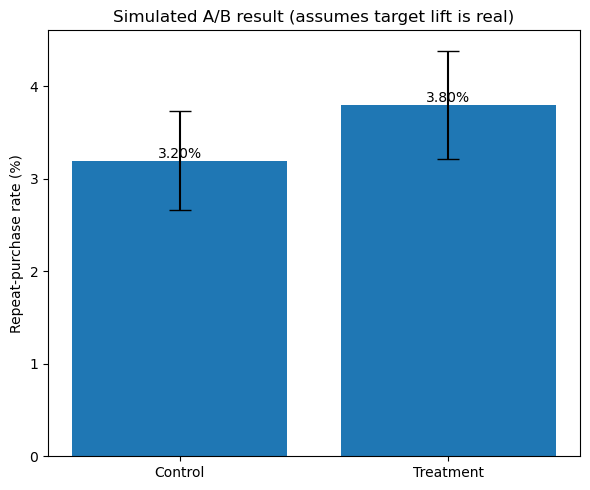

In [19]:
# Visualize the two arms with 95% error bars.
fig, ax = plt.subplots(figsize=(6, 5))
labels = ["Control", "Treatment"]
rates = [rate_c*100, rate_t*100]
errs = [1.96*np.sqrt(rate_c*(1-rate_c)/n_c)*100,
        1.96*np.sqrt(rate_t*(1-rate_t)/n_t)*100]
bars = ax.bar(labels, rates, yerr=errs, capsize=8)
for b, r in zip(bars, rates):
    ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"{r:.2f}%",
            ha="center", va="bottom")
ax.set_ylabel("Repeat-purchase rate (%)")
ax.set_title("Simulated A/B result (assumes target lift is real)")
plt.tight_layout()
plt.savefig("../reports/ab_test_result.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Business impact — translating the lift into money

If the target lift held when rolled out to a typical monthly cohort, how many extra repeat customers, and how
much incremental revenue, would it drive? (Gross of coupon cost — that's a guardrail to weigh separately.)

In [22]:
extra_repeat_customers = typical_monthly * (p1_mde - p0)
incremental_revenue = extra_repeat_customers * aov

print(f"Per typical monthly cohort of ~{typical_monthly:,} customers, a "
      f"{mde_rel*100:.0f}% relative lift implies:")
print(f"  +{extra_repeat_customers:,.0f} additional repeat customers / month")
print(f"  ≈ R$ {incremental_revenue:,.0f} incremental revenue / month (before coupon cost)")
print(f"  ≈ R$ {incremental_revenue*12:,.0f} / year")

Per typical monthly cohort of ~4,130 customers, a 38% relative lift implies:
  +49 additional repeat customers / month
  ≈ R$ 7,880 incremental revenue / month (before coupon cost)
  ≈ R$ 94,557 / year


## 7. Summary & how to state it honestly

Fill in with the numbers your run produced.

**Design summary:**
- Baseline repeat-purchase rate (from data): **[p0]%**
- Test: 50/50 randomized, primary metric = repeat rate within 90 days, α = 0.05, power = 0.80
- Enrollable over ~8 weeks: **[~N]** customers
- **Powered to detect a ~[MDE]% relative lift** ([p0]% → [p1]%)
- If realized on a monthly cohort: **~[extra]** more repeat customers/month, ≈ **R$ [rev]** incremental revenue/month

**Honest resume phrasing** (pick one):
> Designed and analyzed an A/B test for a win-back intervention — hypotheses, 50/50 randomization,
> sample-size/power analysis, and two-proportion significance testing — **powered to detect a ~[MDE]% lift**
> in repeat-purchase rate against a [p0]% baseline.

Note the wording is **"powered to detect a ~[MDE]% lift,"** not "achieved a [MDE]% lift." That is accurate:
the test was designed to detect that effect; it hasn't been run on live customers. In an interview you can
walk through exactly how the number came from the power analysis — which is far stronger than a made-up result.

**Housekeeping when done:**
```
git add .
git commit -m "Add A/B test design (win-back experiment)"
git push
```
